In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import datetime

### Reading Dataset

In [ ]:
df = pd.read_csv("../data_collection/data/dar_to_bhm.csv")
df.columns

Index(['rid', 'toc_code', 'date', 'month', 'day', 'cancelled', 'canc_reason',
       'init_station', 'init_ptd', 'init_atd', 'start_station', 'start_pta',
       'start_ata', 'start_arrival_delay', 'start_ptd', 'start_atd',
       'start_dept_delay', 'distance_from_init', 'end_station', 'end_pta',
       'end_ata', 'end_delay', 'delayed'],
      dtype='str')

In [ ]:
# Step 1: I would like to seperate the trains that were cancelled from the rest.

cancelled_trains = df.loc[lambda df: df['cancelled'] == True, ['rid','toc_code','date','month','day','canc_reason','init_station', 'init_ptd']]

# Load into a new csv file

cancelled_trains.to_csv("cleaned_data/cancelled_trains_dar_to_bhm.csv", index=False)

print(f"{(cancelled_trains.shape[0]/df.shape[0])*100:.2f}% of trains from Darlington to Birmingham were cancelled in the period 2025-09-20 to 2026-09-13.")

4.37% of trains from Darlington to Birmingham were cancelled in the period 2025-09-20 to 2026-09-13.


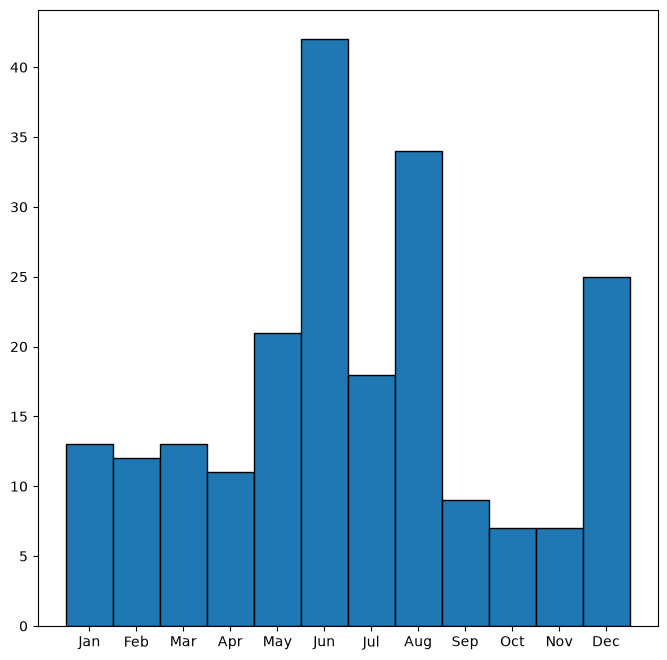

In [69]:
# Plotting Histogram of cancelled trains by month
dates = cancelled_trains['date']

dtm = lambda x: int(x[5:7])
months = list(map(dtm, dates))
fig, ax = plt.subplots(figsize=(8,8))
bins = np.arange(1,14)
ax.hist(months, bins=bins, edgecolor='k', align='left')
ax.set_xticks(bins[:-1])
ax.set_xticklabels([datetime.date(1900,i,1).strftime('%b') for i in bins[:-1]] )

plt.show()

In [47]:
print(f"{100- np.isnan(cancelled_trains['canc_reason']).mean() * 100:.2f}% of the trains cancelled last year were cancelled with reason.")

93.40% of the trains cancelled last year were cancelled with reason.


<Axes: xlabel='canc_reason'>

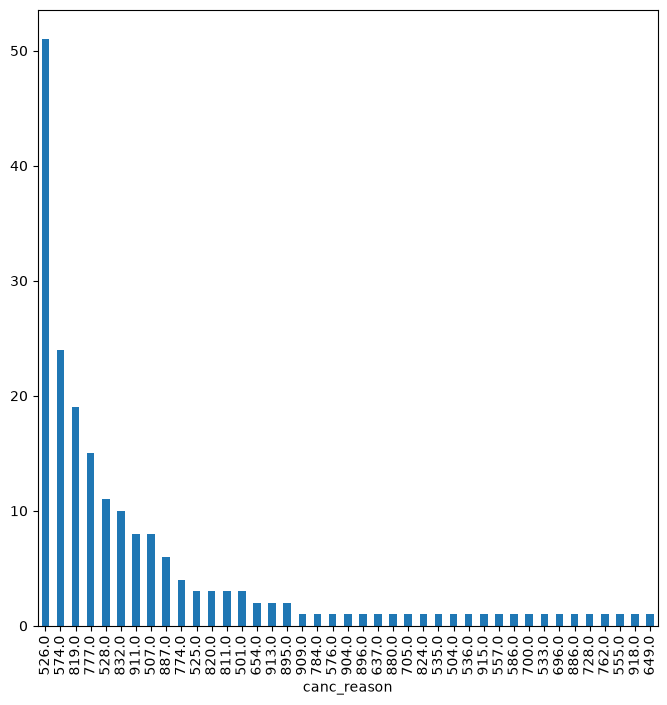

In [51]:
cancelled_trains_reasons = cancelled_trains.dropna(axis=0)
fig, ax = plt.subplots(figsize=(8,8))
cancelled_trains_reasons['canc_reason'].value_counts().plot(ax=ax, kind='bar')

In [77]:
not_cancelled_trains = df.loc[lambda df: df['cancelled'] == False]

# Load into a new csv file

not_cancelled_trains.to_csv("cleaned_data/not_cancelled_trains_dar_to_bhm.csv", index=False)

delayed_trains = not_cancelled_trains['delayed'].value_counts()

print(f"Out of the trains that weren't cancelled, {(delayed_trains[0]/not_cancelled_trains.shape[0])*100:.2f}% arrived on time.")

Out of the trains that weren't cancelled, 28.81% arrived on time.


In [117]:
# Extract Monthly Statistics for not cancelled trains

map = {}


for index, row in not_cancelled_trains.iterrows():
    if row['delayed'] == True:
        if row['month'] in map:
            map[row['month']] += 1
        else:
            map[row['month']] = 1


map

{'SEP': 190,
 'OCT': 271,
 'NOV': 268,
 'DEC': 255,
 'JAN': 224,
 'FEB': 259,
 'MAR': 239,
 'APR': 292,
 'MAY': 280,
 'JUN': 339,
 'JUL': 349,
 'AUG': 336}